# LSTM — An Illustrated Tour

> A **Long Short-Term Memory** cell is an RNN with three gates that decide what to forget, what to write, and what to read out. It can learn dependencies across hundreds of time steps where vanilla RNNs collapse.

---

**What we cover:**
- The cell equations and gates
- Forecasting a noisy multi-frequency sine
- Sliding-window dataset construction
- Train / val loss curves
- One-step and multi-step rollout

## The picture — LSTM cell: gates control what to forget, write, output

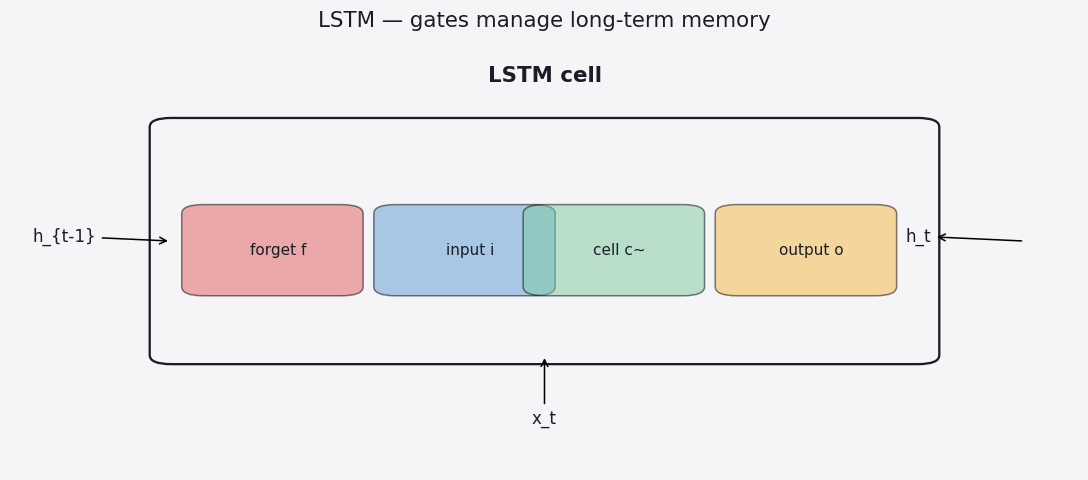

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(10, 4.5)); ax.axis('off')
ax.add_patch(FancyBboxPatch((0.15, 0.25), 0.7, 0.5, boxstyle='round,pad=0.02',
                            facecolor='#f5f5f7', edgecolor='#1a1d27', lw=1.5))
ax.text(0.5, 0.85, 'LSTM cell', ha='center', fontsize=14, weight='bold')
gates = [('forget f', 0.25, P[1]), ('input i', 0.43, P[0]),
         ('cell c~', 0.57, P[3]),  ('output o', 0.75, P[2])]
for n, x, c in gates:
    ax.add_patch(FancyBboxPatch((x-0.07, 0.40), 0.13, 0.16, boxstyle='round,pad=0.02',
                                facecolor=c, alpha=0.5))
    ax.text(x, 0.48, n, ha='center', va='center', fontsize=10)
ax.annotate('h_{t-1}', xy=(0.15, 0.5), xytext=(0.05, 0.5),
            arrowprops=dict(arrowstyle='->'), fontsize=11, ha='center')
ax.annotate('h_t', xy=(0.95, 0.5), xytext=(0.85, 0.5),
            arrowprops=dict(arrowstyle='<-'), fontsize=11, ha='center')
ax.annotate('x_t', xy=(0.5, 0.25), xytext=(0.5, 0.10),
            arrowprops=dict(arrowstyle='->'), fontsize=11, ha='center')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.title('LSTM — gates manage long-term memory', y=0.95)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'
torch.manual_seed(0); np.random.seed(0)

n = 1500
t = np.arange(n)
y = np.sin(2*np.pi*t/40) + 0.5*np.sin(2*np.pi*t/13) + np.random.normal(0, 0.1, n)
y = y.astype(np.float32)
print('Series:', y.shape)

Series: (1500,)


---
## LSTM Cell Equations

$$\begin{aligned}
f_t &= \sigma\bigl(W_f [h_{t-1}, x_t] + b_f\bigr) & \text{forget gate}\\
i_t &= \sigma\bigl(W_i [h_{t-1}, x_t] + b_i\bigr) & \text{input gate}\\
\tilde C_t &= \tanh\bigl(W_c [h_{t-1}, x_t] + b_c\bigr) & \text{candidate cell}\\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde C_t & \text{cell state}\\
o_t &= \sigma\bigl(W_o [h_{t-1}, x_t] + b_o\bigr) & \text{output gate}\\
h_t &= o_t \odot \tanh(C_t) & \text{hidden state}.
\end{aligned}$$

The gates protect $C_t$ from the vanishing-gradient hammer: gradients flow back **through the cell** with a constant identity path when the forget gate is open.

In [3]:
win = 50
X = np.stack([y[i:i+win] for i in range(n - win - 1)])[..., None]
Y = y[win:n - 1]
n_train = int(0.7 * len(X))
Xtr, Xv = X[:n_train], X[n_train:]
Ytr, Yv = Y[:n_train], Y[n_train:]
Xtr_t  = torch.tensor(Xtr); Ytr_t = torch.tensor(Ytr)[:, None]
Xv_t   = torch.tensor(Xv);  Yv_t  = torch.tensor(Yv)[:, None]
print('Train:', Xtr_t.shape, '   Val:', Xv_t.shape)

Train: torch.Size([1014, 50, 1])    Val: torch.Size([435, 50, 1])


In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden=32, layers=1):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1])

net = LSTMForecaster()
opt = torch.optim.Adam(net.parameters(), lr=3e-3)
loss_fn = nn.MSELoss()

epochs = 30
tr_losses, va_losses = [], []
bs = 128
for ep in range(epochs):
    net.train(); perm = torch.randperm(len(Xtr_t))
    losses = []
    for i in range(0, len(perm), bs):
        idx = perm[i:i+bs]
        opt.zero_grad()
        out = net(Xtr_t[idx])
        loss = loss_fn(out, Ytr_t[idx])
        loss.backward(); opt.step()
        losses.append(loss.item())
    net.eval()
    with torch.no_grad():
        va = loss_fn(net(Xv_t), Yv_t).item()
    tr_losses.append(np.mean(losses)); va_losses.append(va)
print('final train MSE:', tr_losses[-1], '   val MSE:', va_losses[-1])

final train MSE: 0.014575590961612761    val MSE: 0.01664835214614868


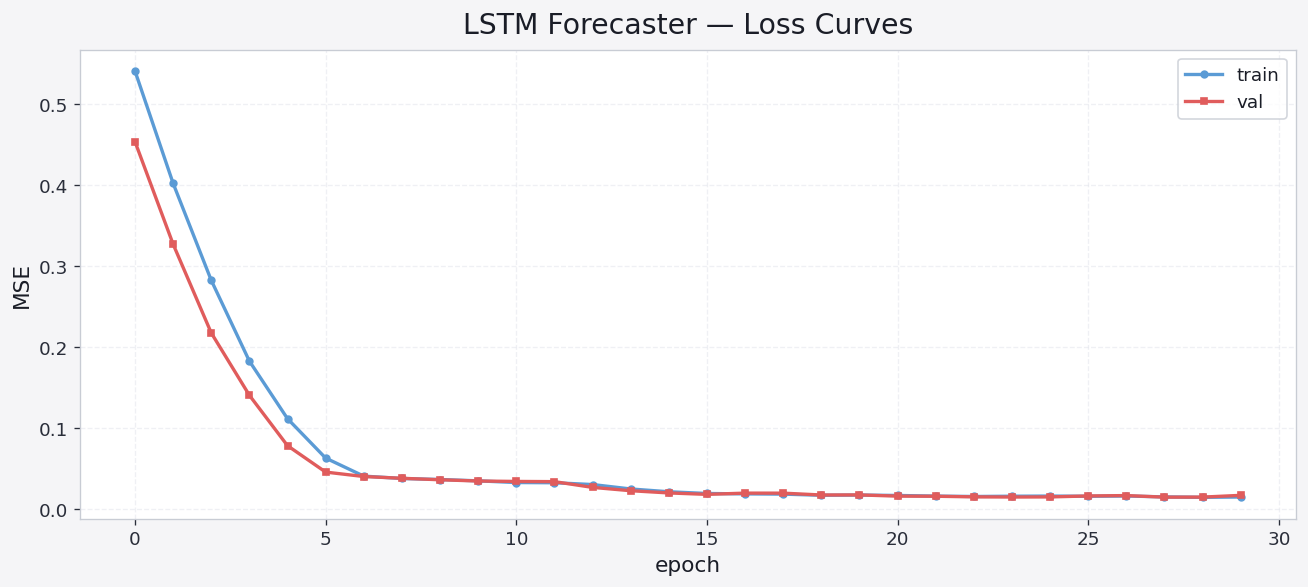

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tr_losses, color=C0, lw=2, marker='o', ms=4, label='train')
ax.plot(va_losses, color=C1, lw=2, marker='s', ms=4, label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE')
ax.set_title('LSTM Forecaster — Loss Curves', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## One-step Forecast on the Validation Set

Each prediction uses the **true** previous 50 values — a *teacher-forced* one-step forecast. Errors don't compound.

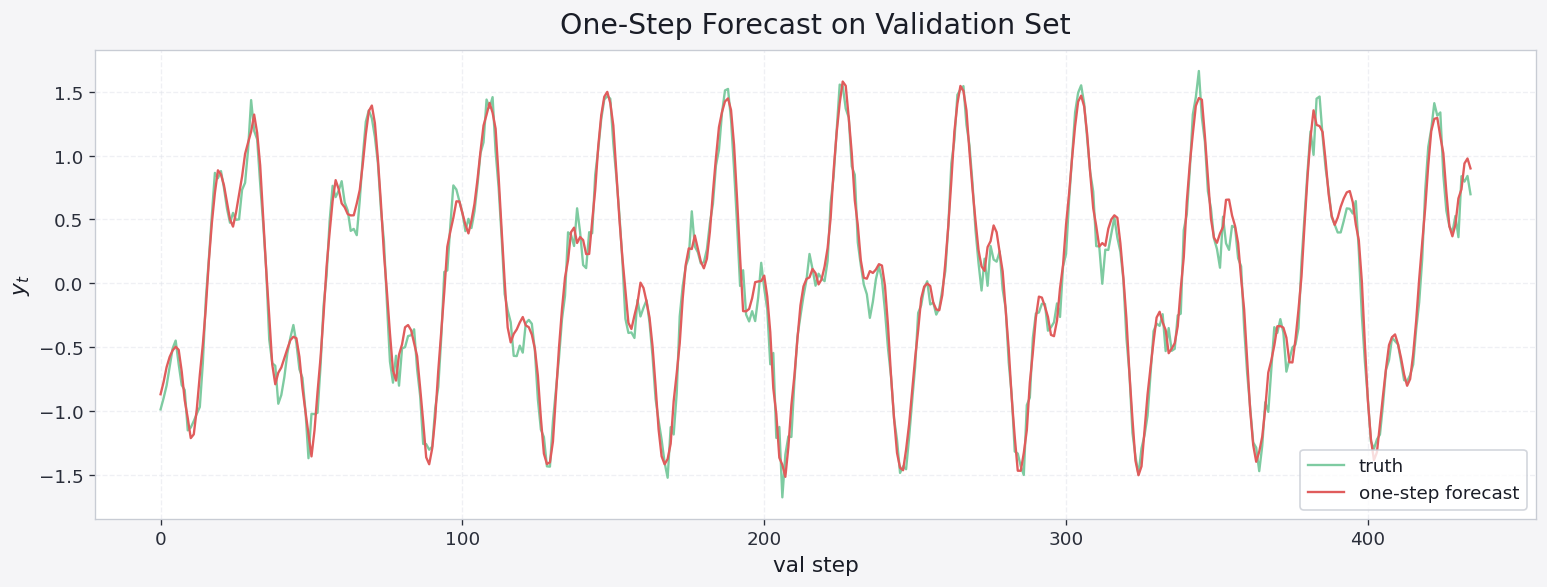

In [6]:
with torch.no_grad():
    yh = net(Xv_t).squeeze(1).numpy()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(Yv,  color=CM, lw=1.4, label='truth')
ax.plot(yh, color=C1, lw=1.4, label='one-step forecast')
ax.set_xlabel('val step'); ax.set_ylabel('$y_t$')
ax.set_title('One-Step Forecast on Validation Set', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Multi-Step Rollout

Feed the model's own predictions back as inputs. Errors compound, especially after several cycles, but the LSTM still tracks both frequencies for a useful horizon.

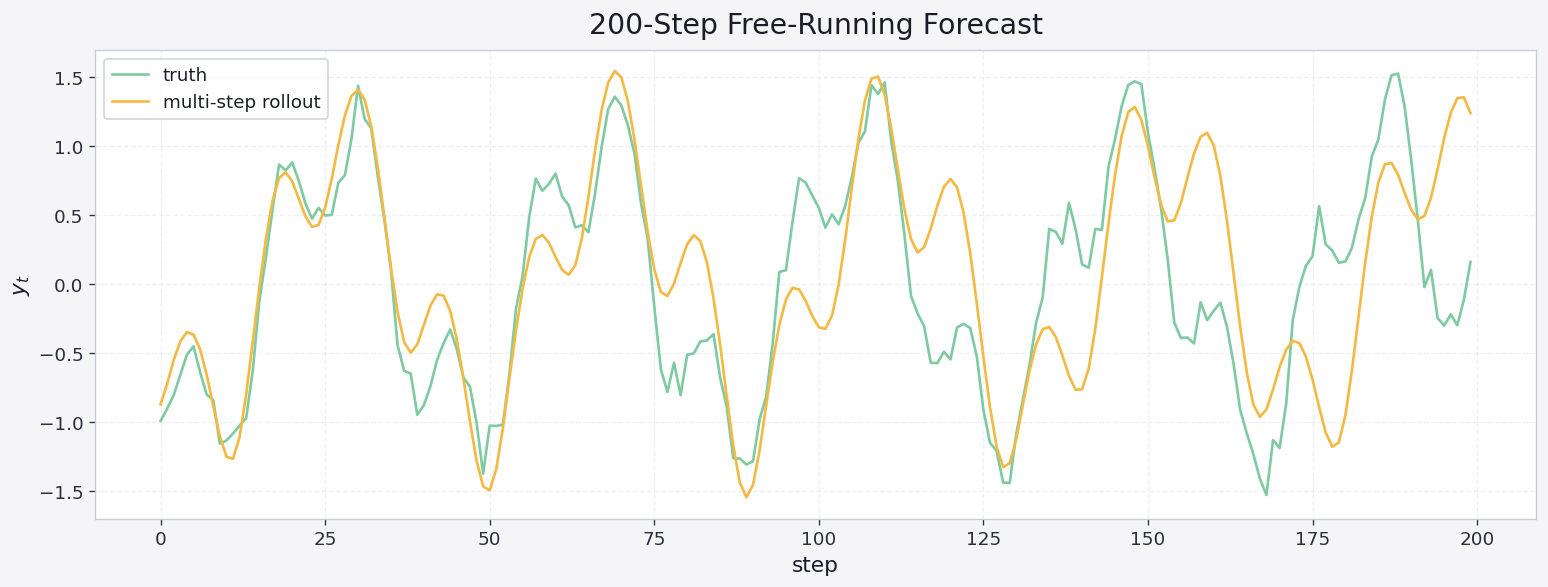

In [7]:
horizon = 200
seed = Xv_t[0].clone()
preds = []
x = seed.unsqueeze(0)
with torch.no_grad():
    for _ in range(horizon):
        p = net(x).squeeze().item()
        preds.append(p)
        x = torch.cat([x[:, 1:], torch.tensor([[[p]]], dtype=torch.float32)], dim=1)

fig, ax = plt.subplots(figsize=(13, 5))
true = Yv[:horizon]
ax.plot(true,  color=CM, lw=1.6, label='truth')
ax.plot(preds, color=CB, lw=1.6, label='multi-step rollout')
ax.set_xlabel('step'); ax.set_ylabel('$y_t$')
ax.set_title(f'{horizon}-Step Free-Running Forecast', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use an LSTM — and when not to

| Situation | LSTM | ARIMA | Prophet | Transformer |
|---|---|---|---|---|
| Many related series, lots of data | ✅ | ❌ | partial | ✅ better |
| Short single series | ❌ overfits | ✅ | ✅ | ❌ |
| Long-range dependencies | ✅ designed for | partial | partial | ✅ better |
| Need uncertainty intervals | ❌ extra work | ✅ | ✅ | partial |

> LSTM is overkill for a single short series. Use it when you have **many series** or rich exogenous features.


---
## 🎯 Try this

1. **Window size.** Try input windows of 10, 30, 90 steps. Too short → can't learn seasonality; too long → harder optimisation.
2. **Vanishing gradients vs ReLU/Tanh.** Replace LSTM with a vanilla RNN — on long sequences it should fail to learn. The forget gate is the key.
3. **Forecast horizon.** Compare 1-step vs multi-step (recursive vs direct multi-output). Errors compound dramatically in recursive forecasting.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| LSTM cell | 4 gates + cell state | Gradient highway through $C_t$ |
| Sliding window | Fixed-length context | Standard supervised setup |
| Teacher forcing | Use true previous values | Stable training |
| Free rollout | Use own predictions | Errors compound |
| Strength | Captures long-range patterns; non-linear; multivariate | Solid for moderate-length sequences |
| Weakness | Sequential → slow training; outclassed by Transformers on long contexts | Use Transformer / Temporal Fusion for big problems |

**Bottom line:** An LSTM is a **gated recurrent network** that learns when to remember and when to forget. For univariate-to-multivariate forecasting on moderate horizons it remains a reliable baseline before reaching for attention-based models.